In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

from sklearn.linear_model    import LogisticRegression, LinearRegression
from sklearn.ensemble        import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster         import KMeans
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, classification_report
)

try:
    from xgboost import XGBClassifier
    USE_XGB = True
    print('XGBoost available')
except ImportError:
    USE_XGB = False
    print('XGBoost not installed — pip install xgboost')

print(' All libraries loaded')

XGBoost available
 All libraries loaded


In [2]:
#DAta_set
Data_set=['matches_1930_2022.csv',
          'world_cup.csv',
          'fifa_ranking_2022-10-06.csv',
          'fifa_ranking_2026-06-08.csv',
          'schedule_2026.csv'
         ]

matches_raw   = pd.read_csv('data/matches_1930_2022.csv')
world_cup_raw = pd.read_csv('data/world_cup.csv')
ranking_2022  = pd.read_csv('data/fifa_ranking_2022-10-06.csv')
ranking_2026  = pd.read_csv('data/fifa_ranking_2026-06-08.csv')
schedule_raw  = pd.read_csv('data/schedule_2026.csv')

print(f'matches_1930_2022 : {matches_raw.shape}')
print(f'world_cup         : {world_cup_raw.shape}')
print(f'ranking_2022      : {ranking_2022.shape}')
print(f'ranking_2026      : {ranking_2026.shape}')
print(f'schedule_2026     : {schedule_raw.shape}')

matches_1930_2022 : (964, 44)
world_cup         : (22, 9)
ranking_2022      : (211, 7)
ranking_2026      : (211, 8)
schedule_2026     : (72, 10)


In [3]:

COUNTRY_MAP = {
    'USA':                       'United States',
    'US':                        'United States',
    
    'Korea Republic':            'South Korea',
    'Republic of Korea':         'South Korea',
    'Korea DPR':                 'North Korea',
    'IR Iran':                   'Iran',
    'Islamic Republic of Iran':  'Iran',
    'China PR':                  'China',
    
    "Cote d'Ivoire":             "Côte d'Ivoire",
    'Ivory Coast':               "Côte d'Ivoire",
    
    'Czech Republic':            'Czechia',
    'Bosnia and Herzegovina':    'Bosnia-Herzegovina',
    'Bosnia & Herzegovina':      'Bosnia-Herzegovina',
    'Türkiye':                   'Turkey',
    
    'West Germany':              'Germany',
    'East Germany':              'Germany',
    'Soviet Union':              'Russia',
    'Yugoslavia':                'Serbia',
    'Czechoslovakia':            'Czechia',
    'German DR':                 'Germany',
    'Dutch East Indies':         'Indonesia',
}

def normalise_country(name: str) -> str:
    """Strip whitespace and apply COUNTRY_MAP; return canonical team name."""
    if pd.isna(name):
        return np.nan
    name = str(name).strip()
    return COUNTRY_MAP.get(name, name)

matches_raw['home_team'] = matches_raw['home_team'].apply(normalise_country)
matches_raw['away_team'] = matches_raw['away_team'].apply(normalise_country)

ranking_2022['team'] = ranking_2022['team'].apply(normalise_country)
ranking_2026['team'] = ranking_2026['team'].apply(normalise_country)

schedule_raw['home_team'] = schedule_raw['home_team'].apply(normalise_country)
schedule_raw['away_team'] = schedule_raw['away_team'].apply(normalise_country)

world_cup_raw['Champion']   = world_cup_raw['Champion'].apply(normalise_country)
world_cup_raw['Runner-Up']  = world_cup_raw['Runner-Up'].apply(normalise_country)

print('Country names normalised across all datasets')

Country names normalised across all datasets


In [4]:
matches = matches_raw.copy()
KEEP_COLS = ['Year', 'home_team', 'away_team', 'home_score', 'away_score', 'Round']
matches = matches[KEEP_COLS].copy()

matches['Year']       = pd.to_numeric(matches['Year'],       errors='coerce')
matches['home_score'] = pd.to_numeric(matches['home_score'], errors='coerce')
matches['away_score'] = pd.to_numeric(matches['away_score'], errors='coerce')

before = len(matches)
matches.dropna(subset=['Year','home_team','away_team','home_score','away_score'],
               inplace=True)
matches.reset_index(drop=True, inplace=True)
print(f'Rows before: {before} | after: {len(matches)} | dropped: {before - len(matches)}')

matches['total_goals'] = matches['home_score'] + matches['away_score']

#NaN
nan_check = matches[['home_team','away_team','home_score','away_score']].isna().sum()
assert nan_check.sum() == 0, f'NaN found: {nan_check}'
print('Zero NaN values in critical columns')
matches.head(3)

Rows before: 964 | after: 964 | dropped: 0
Zero NaN values in critical columns


,Year,home_team,away_team,home_score,away_score,Round,total_goals
0,2022,Argentina,France,3,3,Final,6
1,2022,Croatia,Morocco,2,1,Third-place match,3
2,2022,France,Morocco,2,0,Semi-finals,2


In [5]:
def encode_result(home_score, away_score) -> int:
    """Return 0 = Home Win, 1 = Away Win, 2 = Draw."""
    if home_score > away_score:
        return 0
    elif away_score > home_score:
        return 1
    else:
        return 2

matches['Match_Result'] = matches.apply(
    lambda r: encode_result(r['home_score'], r['away_score']), axis=1
)

label_names = {0: 'Home Win', 1: 'Away Win', 2: 'Draw'}
dist = matches['Match_Result'].map(label_names).value_counts()
print('Match result distribution:')
print(dist.to_string())
print(f'\nTotal matches: {len(matches)}')

Match result distribution:
Match_Result
Home Win    532
Away Win    218
Draw        214

Total matches: 964


In [6]:
print('=== Summary Statistics ===')
print(matches[['home_score','away_score','total_goals']].describe().round(3))

print('\n=== Correlation Matrix ===')
print(matches[['home_score','away_score','total_goals','Match_Result']].corr().round(3))

=== Summary Statistics ===
       home_score  away_score  total_goals
count     964.000     964.000      964.000
mean        1.777       1.045        2.822
std         1.597       1.071        1.927
min         0.000       0.000        0.000
25%         1.000       0.000        1.000
50%         1.000       1.000        3.000
75%         3.000       2.000        4.000
max        10.000       7.000       12.000

=== Correlation Matrix ===
              home_score  away_score  total_goals  Match_Result
home_score         1.000       0.005        0.831        -0.524
away_score         0.005       1.000        0.560         0.218
total_goals        0.831       0.560        1.000        -0.313
Match_Result      -0.524       0.218       -0.313         1.000


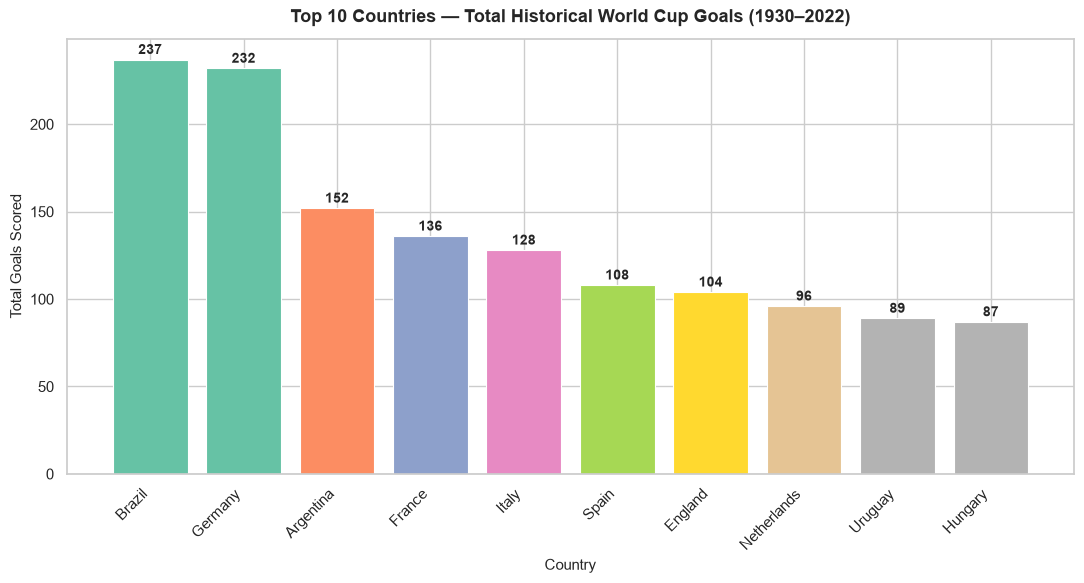

Saved: top10_goals.png


In [7]:
home_goals = matches.groupby('home_team')['home_score'].sum()
away_goals = matches.groupby('away_team')['away_score'].sum()
total_by_team = (home_goals
                 .add(away_goals, fill_value=0)
                 .sort_values(ascending=False)
                 .head(10))

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.Set2(np.linspace(0, 1, len(total_by_team)))
bars = ax.bar(total_by_team.index, total_by_team.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, total_by_team.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            str(int(val)), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Countries — Total Historical World Cup Goals (1930–2022)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Country', fontsize=11)
ax.set_ylabel('Total Goals Scored', fontsize=11)
plt.xticks(rotation=45, ha='right')   
plt.tight_layout()
plt.savefig('top10_goals.png', dpi=150)
plt.show()
print('Saved: top10_goals.png')

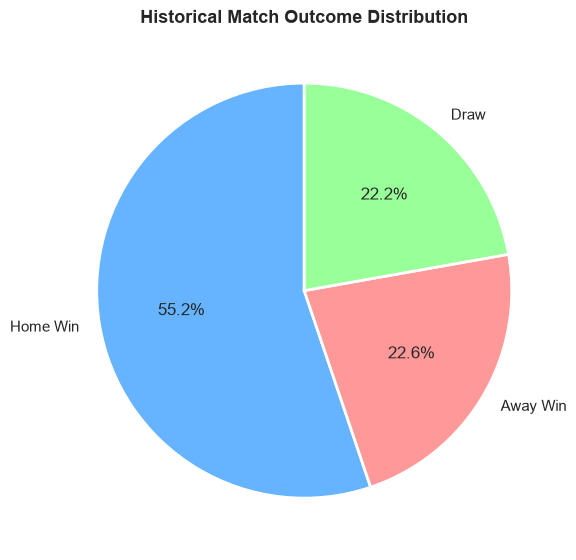

In [8]:
result_counts = matches['Match_Result'].map(label_names).value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(result_counts.values,
       labels=result_counts.index,
       autopct='%1.1f%%',
       colors=['#66b3ff','#ff9999','#99ff99'],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2}
      )
ax.set_title('Historical Match Outcome Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outcome_distribution.png', dpi=150)
plt.show()

In [9]:
home_side = matches[['home_team','home_score','away_score','Match_Result']].copy()
home_side.columns = ['team','gf','ga','result']
home_side['win'] = (home_side['result'] == 0).astype(int)

away_side = matches[['away_team','away_score','home_score','Match_Result']].copy()
away_side.columns = ['team','gf','ga','result']
away_side['win'] = (away_side['result'] == 1).astype(int)

all_sides = pd.concat([home_side, away_side], ignore_index=True)

team_stats = (
    all_sides
    .groupby('team')
    .agg(
        matches_played = ('gf', 'count'),
        total_wins     = ('win', 'sum'),
        total_gf       = ('gf',  'sum'),
        total_ga       = ('ga',  'sum'),
    )
    .reset_index()
)

team_stats['win_ratio']        = team_stats['total_wins'] / team_stats['matches_played']
team_stats['avg_goals_scored'] = team_stats['total_gf']   / team_stats['matches_played']
team_stats['avg_goal_diff']    = (team_stats['total_gf'] - team_stats['total_ga']) / team_stats['matches_played']

print('Team stats (top 10 by win ratio):')
team_stats.sort_values('win_ratio', ascending=False).head(10)[[
    'team','matches_played','win_ratio','avg_goals_scored','avg_goal_diff'
]].reset_index(drop=True)

Team stats (top 10 by win ratio):


,team,matches_played,win_ratio,avg_goals_scored,avg_goal_diff
0,Brazil,114,0.666667,2.078947,1.131579
1,Germany,112,0.607143,2.071429,0.910714
2,Netherlands,55,0.545455,1.745455,0.800000
3,Italy,83,0.542169,1.542169,0.614458
4,France,73,0.534247,1.863014,0.698630
5,Argentina,88,0.534091,1.727273,0.579545
6,Turkey,10,0.500000,2.000000,0.300000
7,FR Yugoslavia,4,0.500000,1.250000,0.250000
8,Portugal,35,0.485714,1.742857,0.571429
9,Hungary,32,0.468750,2.718750,0.937500


In [10]:

rank_cols = ['team','rank','points']
rank22 = ranking_2022[rank_cols].rename(columns={'rank':'fifa_rank','points':'fifa_points'})
rank26 = ranking_2026[rank_cols].rename(columns={'rank':'fifa_rank','points':'fifa_points'})

STAT_COLS = ['team','win_ratio','avg_goals_scored','avg_goal_diff']

def add_team_features(df, stat_df, rank_df):
    """
    Left-join historical stats and FIFA ranking for both home and away teams.
    Fills NaN with 0 so new/rare teams don't break the model.
    """
    df = df.merge(
        stat_df[STAT_COLS].rename(columns={c: f'home_{c}' for c in STAT_COLS if c != 'team'}),
        left_on='home_team', right_on='team', how='left'
    ).drop(columns='team')

    df = df.merge(
        stat_df[STAT_COLS].rename(columns={c: f'away_{c}' for c in STAT_COLS if c != 'team'}),
        left_on='away_team', right_on='team', how='left'
    ).drop(columns='team')

    df = df.merge(
        rank_df.rename(columns={'team':'home_team','fifa_rank':'home_fifa_rank','fifa_points':'home_fifa_points'}),
        on='home_team', how='left'
    )
    df = df.merge(
        rank_df.rename(columns={'team':'away_team','fifa_rank':'away_fifa_rank','fifa_points':'away_fifa_points'}),
        on='away_team', how='left'
    )

    fill_cols = [
        'home_win_ratio','home_avg_goals_scored','home_avg_goal_diff',
        'away_win_ratio','away_avg_goals_scored','away_avg_goal_diff',
        'home_fifa_rank','home_fifa_points','away_fifa_rank','away_fifa_points'
    ]
    for col in fill_cols:
        df[col] = df[col].fillna(0)

    df['diff_win_ratio']     = df['home_win_ratio']        - df['away_win_ratio']
    df['diff_goals_scored']  = df['home_avg_goals_scored'] - df['away_avg_goals_scored']
    df['diff_goal_diff']     = df['home_avg_goal_diff']    - df['away_avg_goal_diff']
    df['diff_fifa_points']   = df['home_fifa_points']      - df['away_fifa_points']

    return df

matches_feat = add_team_features(matches.copy(), team_stats, rank22)

FEATURE_COLS = [
    'home_win_ratio',      'home_avg_goals_scored', 'home_avg_goal_diff',
    'away_win_ratio',      'away_avg_goals_scored', 'away_avg_goal_diff',
    'diff_win_ratio',      'diff_goals_scored',     'diff_goal_diff',
    'home_fifa_points',    'away_fifa_points',       'diff_fifa_points'
]

nan_count = matches_feat[FEATURE_COLS].isna().sum().sum()
assert nan_count == 0, f'NaN found in features: {nan_count}'
print(f'Feature matrix ready — {len(matches_feat)} rows × {len(FEATURE_COLS)} features')
print('Features:', FEATURE_COLS)

Feature matrix ready — 964 rows × 12 features
Features: ['home_win_ratio', 'home_avg_goals_scored', 'home_avg_goal_diff', 'away_win_ratio', 'away_avg_goals_scored', 'away_avg_goal_diff', 'diff_win_ratio', 'diff_goals_scored', 'diff_goal_diff', 'home_fifa_points', 'away_fifa_points', 'diff_fifa_points']


In [11]:
TARGET = 'Match_Result'

train_df = matches_feat[matches_feat['Year'] <= 2018].copy()
test_df  = matches_feat[matches_feat['Year'] == 2022].copy()

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET]

print(f'Train size : {len(X_train)} matches (1930–2018)')
print(f'Test  size : {len(X_test)}  matches (2022 only)')
print('\nClass distribution (train):', y_train.value_counts().map(label_names).to_dict())
print('Class distribution (test) :', y_test.value_counts().map(label_names).to_dict())

Train size : 900 matches (1930–2018)
Test  size : 64  matches (2022 only)

Class distribution (train): {0: nan, 2: nan, 1: nan}
Class distribution (test) : {0: nan, 1: nan, 2: nan}


In [12]:
lr = LogisticRegression(max_iter=2000, random_state=42,) #multi_class='multinomial')
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
lr_f1  = f1_score(y_test, lr_preds, average='macro', zero_division=0)

print('=== Logistic Regression (Baseline) ===')
print(f'Accuracy  : {lr_acc:.4f}')
print(f'Precision : {precision_score(y_test, lr_preds, average="macro", zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_test, lr_preds, average="macro", zero_division=0):.4f}')
print(f'Macro F1  : {lr_f1:.4f}')
print('\nDetailed Report:')
print(classification_report(y_test, lr_preds, target_names=['Home Win','Away Win','Draw'], zero_division=0))

=== Logistic Regression (Baseline) ===
Accuracy  : 0.5156
Precision : 0.4965
Recall    : 0.4366
Macro F1  : 0.4046

Detailed Report:
              precision    recall  f1-score   support

    Home Win       0.56      0.79      0.66        29
    Away Win       0.43      0.45      0.44        20
        Draw       0.50      0.07      0.12        15

    accuracy                           0.52        64
   macro avg       0.50      0.44      0.40        64
weighted avg       0.51      0.52      0.46        64



In [13]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8,min_samples_split=5, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1  = f1_score(y_test, rf_preds, average='macro', zero_division=0)

print('=== Random Forest Classifier ===')
print(f'Accuracy  : {rf_acc:.4f}')
print(f'Precision : {precision_score(y_test, rf_preds, average="macro", zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_test, rf_preds, average="macro", zero_division=0):.4f}')
print(f'Macro F1  : {rf_f1:.4f}')
print('\nDetailed Report:')
print(classification_report(y_test, rf_preds, target_names=['Home Win','Away Win','Draw'], zero_division=0))

=== Random Forest Classifier ===
Accuracy  : 0.4844
Precision : 0.4799
Recall    : 0.4831
Macro F1  : 0.4753

Detailed Report:
              precision    recall  f1-score   support

    Home Win       0.64      0.48      0.55        29
    Away Win       0.43      0.50      0.47        20
        Draw       0.37      0.47      0.41        15

    accuracy                           0.48        64
   macro avg       0.48      0.48      0.48        64
weighted avg       0.51      0.48      0.49        64



In [14]:
if USE_XGB:
    xgb = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        eval_metric='mlogloss', random_state=42
    )
    xgb.fit(X_train, y_train)
    xgb_preds = xgb.predict(X_test)

    xgb_acc = accuracy_score(y_test, xgb_preds)
    xgb_f1  = f1_score(y_test, xgb_preds, average='macro', zero_division=0)

    print('=== XGBoost Classifier ===')
    print(f'Accuracy  : {xgb_acc:.4f}')
    print(f'Precision : {precision_score(y_test, xgb_preds, average="macro", zero_division=0):.4f}')
    print(f'Recall    : {recall_score(y_test, xgb_preds, average="macro", zero_division=0):.4f}')
    print(f'Macro F1  : {xgb_f1:.4f}')
    print('\nDetailed Report:')
    print(classification_report(y_test, xgb_preds,
                                target_names=['Home Win','Away Win','Draw'], zero_division=0))

    best_clf = xgb
    print('\n Best classifier → XGBoost')
else:
    xgb_acc, xgb_f1 = 0, 0
    best_clf = rf
    print(' XGBoost unavailable — using Random Forest as best classifier')

=== XGBoost Classifier ===
Accuracy  : 0.4375
Precision : 0.4005
Recall    : 0.3954
Macro F1  : 0.3955

Detailed Report:
              precision    recall  f1-score   support

    Home Win       0.50      0.59      0.54        29
    Away Win       0.47      0.40      0.43        20
        Draw       0.23      0.20      0.21        15

    accuracy                           0.44        64
   macro avg       0.40      0.40      0.40        64
weighted avg       0.43      0.44      0.43        64


 Best classifier → XGBoost


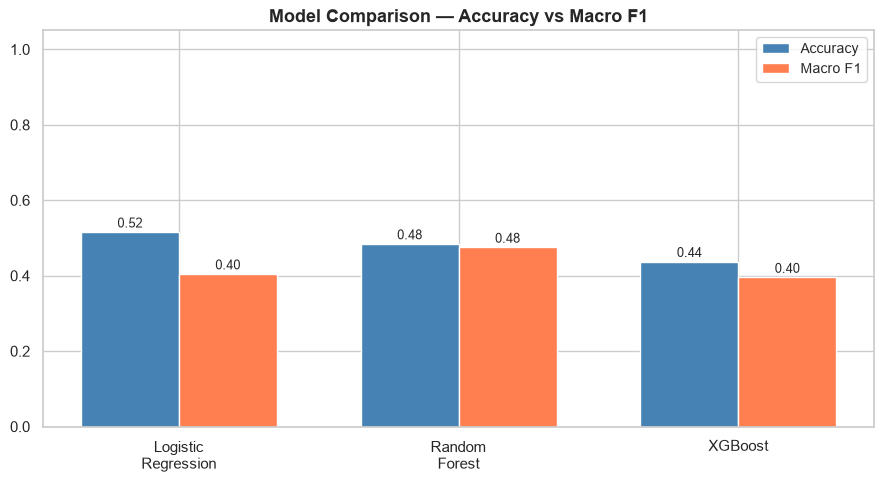

Saved: model_comparison.png


In [15]:
model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
accuracies  = [lr_acc,  rf_acc,  xgb_acc  if USE_XGB else 0]
f1_scores   = [lr_f1,   rf_f1,   xgb_f1   if USE_XGB else 0]
x = np.arange(len(model_names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, accuracies, w, label='Accuracy',  color='steelblue', edgecolor='white')
b2 = ax.bar(x + w/2, f1_scores,  w, label='Macro F1',  color='coral',     edgecolor='white')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Accuracy vs Macro F1', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Saved: model_comparison.png')

In [16]:
def build_fixture_row(home_team: str, away_team: str):

    def get_stats(team):
        row = team_stats[team_stats['team'] == team]

        if row.empty:
            return 0.0, 0.0, 0.0

        row = row.iloc[0]      

        return (
            float(row['win_ratio']),
            float(row['avg_goals_scored']),
            float(row['avg_goal_diff'])
        )

    def get_fifa_pts(team):
        row = rank26[rank26['team'] == team]

        if row.empty:
            return 0.0

        return float(row.iloc[0]['fifa_points'])

    h_wr, h_ag, h_gd = get_stats(home_team)
    a_wr, a_ag, a_gd = get_stats(away_team)

    h_pts = get_fifa_pts(home_team)
    a_pts = get_fifa_pts(away_team)

    return pd.DataFrame([{
        'home_win_ratio': h_wr,
        'home_avg_goals_scored': h_ag,
        'home_avg_goal_diff': h_gd,

        'away_win_ratio': a_wr,
        'away_avg_goals_scored': a_ag,
        'away_avg_goal_diff': a_gd,

        'diff_win_ratio': h_wr - a_wr,
        'diff_goals_scored': h_ag - a_ag,
        'diff_goal_diff': h_gd - a_gd,

        'home_fifa_points': h_pts,
        'away_fifa_points': a_pts,
        'diff_fifa_points': h_pts - a_pts,
    }])[FEATURE_COLS]

In [17]:
X_train_r = train_df[FEATURE_COLS]
y_train_r = train_df['total_goals']
X_test_r  = test_df[FEATURE_COLS]
y_test_r  = test_df['total_goals']

lin = LinearRegression()
lin.fit(X_train_r, y_train_r)
lin_pred = lin.predict(X_test_r)
lin_rmse = np.sqrt(mean_squared_error(y_test_r, lin_pred))
lin_mae  = mean_absolute_error(y_test_r, lin_pred)

rf_reg = RandomForestRegressor(n_estimators=300, max_depth=8,
                                random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
rf_pred_r = rf_reg.predict(X_test_r)
rf_rmse   = np.sqrt(mean_squared_error(y_test_r, rf_pred_r))
rf_mae    = mean_absolute_error(y_test_r, rf_pred_r)

print('=== Regression: Total Goals Prediction ===')
print(f'Linear Regression    →  RMSE: {lin_rmse:.3f}  |  MAE: {lin_mae:.3f}')
print(f'Random Forest Reg    →  RMSE: {rf_rmse:.3f}  |  MAE: {rf_mae:.3f}')

=== Regression: Total Goals Prediction ===
Linear Regression    →  RMSE: 1.796  |  MAE: 1.397
Random Forest Reg    →  RMSE: 1.891  |  MAE: 1.491


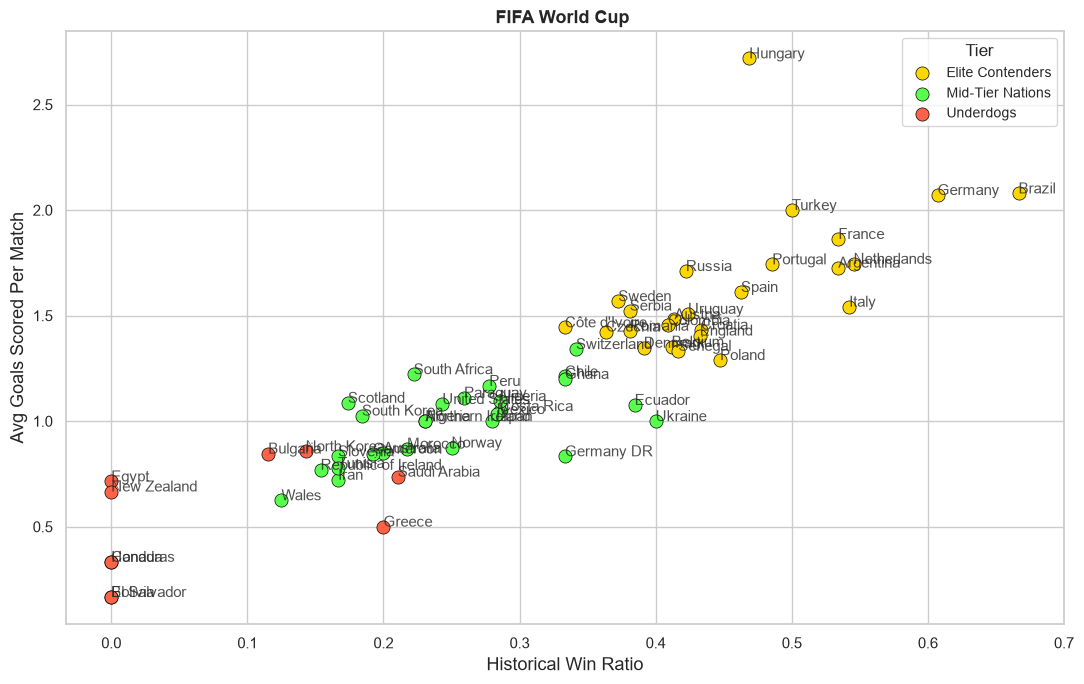

Elite Contenders:
['Argentina', 'Austria', 'Belgium', 'Brazil', 'Colombia', 'Croatia', 'Czechia', "Côte d'Ivoire", 'Denmark', 'England', 'France', 'Germany', 'Hungary', 'Italy', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Russia', 'Senegal', 'Serbia', 'Spain', 'Sweden', 'Turkey', 'Uruguay']


In [18]:

cluster_input = team_stats[team_stats['matches_played'] >= 5].copy()
CLUSTER_FEATURES = ['win_ratio', 'avg_goals_scored', 'avg_goal_diff']

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(cluster_input[CLUSTER_FEATURES])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_input['cluster'] = kmeans.fit_predict(X_scaled)

means = cluster_input.groupby('cluster')['win_ratio'].mean().sort_values(ascending=False)
TIER_MAP = {means.index[0]: 'Elite Contenders',
            means.index[1]: 'Mid-Tier Nations',
            means.index[2]: 'Underdogs'}
cluster_input['tier'] = cluster_input['cluster'].map(TIER_MAP)

TIER_COLORS = {'Elite Contenders': 'gold', 'Mid-Tier Nations': '#58ff4d', 'Underdogs': 'tomato'}

fig, ax = plt.subplots(figsize=(11, 7))
for tier, grp in cluster_input.groupby('tier'):
    ax.scatter(grp['win_ratio'], grp['avg_goals_scored'],
               c=TIER_COLORS[tier], label=tier,
               s=90, edgecolors='black', linewidths=0.5, zorder=3)
    for _, r in grp.iterrows():
        ax.annotate(r['team'], (r['win_ratio'], r['avg_goals_scored']),
                    fontsize=11, alpha=0.8)

ax.set_xlabel('Historical Win Ratio', fontsize=13)
ax.set_ylabel('Avg Goals Scored Per Match', fontsize=13)
ax.set_title('FIFA World Cup ', fontsize=13, fontweight='bold')
ax.legend(title='Tier', fontsize=10)
plt.tight_layout()
plt.savefig('team_clusters.png', dpi=150)
plt.show()

print('Elite Contenders:')
print(sorted(cluster_input[cluster_input['tier']=='Elite Contenders']['team'].tolist()))

In [19]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [4, 6, 8],
    'min_samples_split': [2, 5],
}

grid_cv = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_cv.fit(X_train, y_train)

tuned_rf    = grid_cv.best_estimator_
tuned_preds = tuned_rf.predict(X_test)
tuned_acc   = accuracy_score(y_test, tuned_preds)

print(f'Best parameters : {grid_cv.best_params_}')
print(f'Before tuning   : {rf_acc:.4f}')
print(f'After tuning    : {tuned_acc:.4f}')
print(f'Accuracy jump   : {(tuned_acc - rf_acc)*100:+.2f}%')

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters : {'max_depth': 4, 'min_samples_split': 5, 'n_estimators': 300}
Before tuning   : 0.4844
After tuning    : 0.4844
Accuracy jump   : +0.00%
